# HELICOID Dataset Analysis and Visualization

This notebook provides comprehensive analysis and visualization of the HELICOID hyperspectral imaging dataset.

## Contents
1. Dataset Loading and Basic Statistics
2. Spectral Analysis
3. Spatial Analysis and Ground Truth Visualization
4. Sample Comparison
5. Data Quality Assessment
6. Advanced Visualizations

## 1. Setup and Imports

In [1]:
import sys
import os
from pathlib import Path

# Add project root to path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
from typing import List, Dict, Tuple
from src.visualize_data import show_interactive_image_with_spectrum
from src.wavelength_selection.enums import SampleType
import warnings

warnings.filterwarnings("ignore")

# Set up plotting style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
%matplotlib inline

print("Setup complete!")

Loaded 61 patient IDs from metadata CSV
Setup complete!


In [2]:
# Import the HELICOID dataset class
from src.dataset.helicoid_dataset import HelicoidDataset
from src.constants import HELICOID_DATA_DIR, HELICOID_WAVELENGTHS

print(f"HELICOID data directory: {HELICOID_DATA_DIR}")
print(f"Directory exists: {HELICOID_DATA_DIR.exists()}")
print(f"HELICOID wavelengths: {HELICOID_WAVELENGTHS.shape}")

HELICOID data directory: /home/ezhovi/npj_database
Directory exists: True
HELICOID wavelengths: (826,)


## 2. Dataset Loading and Basic Statistics

In [4]:
# Create dataset instance with basic parameters
dataset = HelicoidDataset(
    coarseness=1, 
    normalize_image=True,
    with_delta_A=True,
    with_rgb=True,
    inference_mode=True
)

print(f"Dataset loaded successfully!")
print(f"Total number of patients: {len(dataset)}")
print(f"Wavelength range: {dataset.cut_wavelengths[0]:.1f} - {dataset.cut_wavelengths[-1]:.1f} nm")
print(f"Number of spectral bands: {len(dataset.cut_wavelengths)}")

2025-09-23 17:01:35.312 | DEBUG    | src.dataset.helicoid_dataset:_find_patient_samples:210 - Found 70 valid HELICOID patient samples


Initialized wavelengths: 302 bands in range [530, 750)
Dataset loaded successfully!
Total number of patients: 70
Wavelength range: 530.7 - 749.7 nm
Number of spectral bands: 302


In [4]:
# Get basic dataset statistics
patient_ids = dataset.get_patient_ids()
print("Patient IDs in dataset:")
for i, pid in enumerate(patient_ids):
    if i % 6 == 0:
        print()
    print(f"{pid:>8}", end="  ")
print(f"\n\nTotal patients: {len(patient_ids)}")

# Get dataset summary
summary = dataset.get_summary()
print("\nDataset Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

Patient IDs in dataset:

     004       005       007       008       010       012  
     013       014       015       016       017       018  
     019       020       021       022       025       026  
     027       028       029       030       034       035  
     036       037       038       039       040       041  
     042       043       050       051       053       054  
     055       056       057       058  

Total patients: 40

Dataset Summary:
  total_samples: 70
  num_patients: 40
  patient_ids: ['004', '005', '007', '008', '010', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '025', '026', '027', '028', '029', '030', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '050', '051', '053', '054', '055', '056', '057', '058']
  patient_fov_counts: {'004': 1, '005': 1, '007': 1, '008': 2, '010': 1, '012': 2, '013': 1, '014': 1, '015': 1, '016': 5, '017': 1, '018': 2, '019': 1, '020': 1, '021': 3, '022': 3, '025': 1, '0

In [5]:
# Analyze data dimensions across samples
sample_info = []
print("Analyzing sample dimensions...")

for i in range(min(10, len(dataset))):  # Analyze first 10 samples
    sample = dataset[i]
    
    sample_info.append({
        'id': sample['id'],
        'hsi_shape': sample['hsi_cube'].shape,
        'gt_shape': sample['gt_map'].shape,
        'rgb_size': sample['rgb_image'].size,
        'spectral_bands': len(sample['wavelengths'])
    })

# Create DataFrame for easy analysis
df_info = pd.DataFrame(sample_info)
print("\nSample dimensions (first 10 patients):")
print(df_info.to_string(index=False))

Analyzing sample dimensions...

Sample dimensions (first 10 patients):
    id       hsi_shape   gt_shape   rgb_size  spectral_bands
004-02 (302, 224, 224) (224, 224) (345, 389)             302
005-01 (302, 224, 224) (224, 224) (488, 483)             302
007-01 (302, 224, 224) (224, 224) (400, 582)             302
008-01 (302, 224, 224) (224, 224) (549, 460)             302
008-02 (302, 224, 224) (224, 224) (553, 480)             302
010-03 (302, 224, 224) (224, 224) (461, 371)             302
012-01 (302, 224, 224) (224, 224) (497, 443)             302
012-02 (302, 224, 224) (224, 224) (498, 445)             302
013-01 (302, 224, 224) (224, 224) (253, 298)             302
014-01 (302, 224, 224) (224, 224) (244, 317)             302


## 3. Ground Truth Label Analysis

In [6]:
# Analyze ground truth labels across the dataset
print("Computing label statistics across all samples...")
label_stats = dataset.get_label_statistics()

print("\nLabel Distribution:")
for label, count in label_stats['label_counts'].items():
    percentage = label_stats['label_percentages'][label]
    print(f"Label {label}: {count} pixels ({percentage:5.2f}%)")

print(f"\nTotal pixels analyzed: {label_stats['total_pixels']:,}")

Computing label statistics across all samples...


KeyboardInterrupt: 

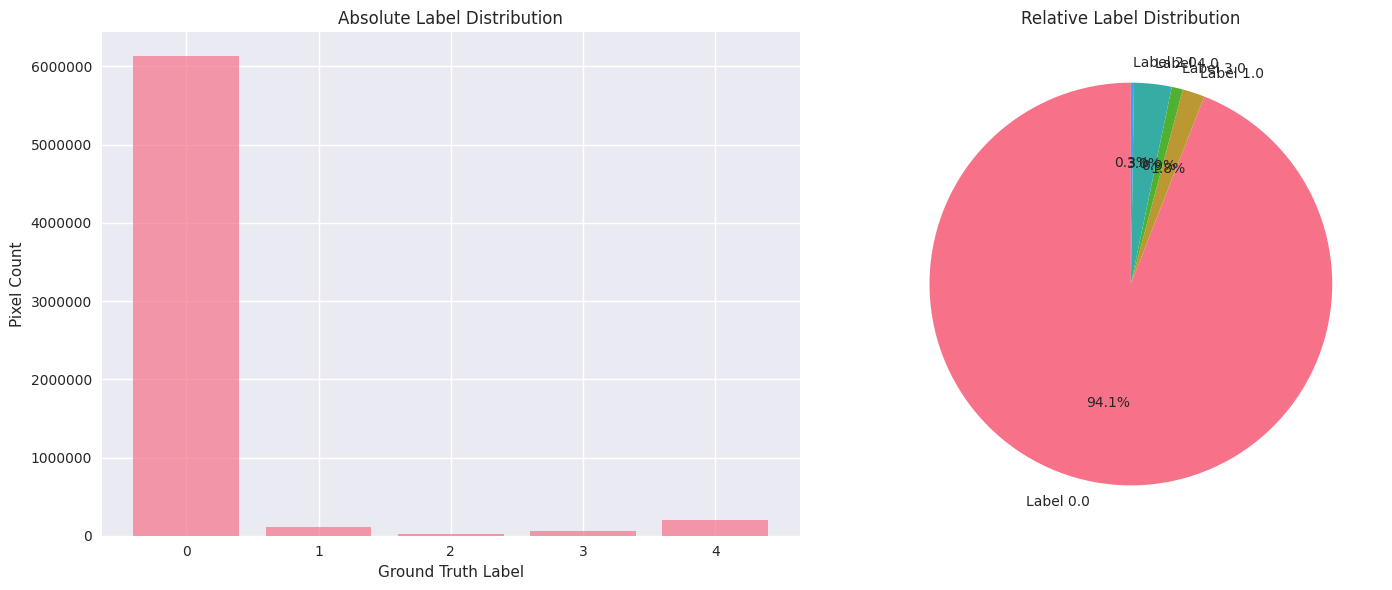


Label Interpretation (typical for HELICOID):
Label 0.0: Background
Label 1.0: Normal Tissue
Label 3.0: Blood Vessels
Label 4.0: Unknown
Label 2.0: Tumor Tissue


In [ ]:
# Visualize label distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot of absolute counts
labels = list(label_stats['label_counts'].keys())
counts = list(label_stats['label_counts'].values())
percentages = list(label_stats['label_percentages'].values())

ax1.bar(labels, counts, alpha=0.7)
ax1.set_xlabel('Ground Truth Label')
ax1.set_ylabel('Pixel Count')
ax1.set_title('Absolute Label Distribution')
ax1.ticklabel_format(style='plain', axis='y')

# Pie chart of percentages
label_names = [f'Label {label}' for label in labels]
ax2.pie(percentages, labels=label_names, autopct='%1.1f%%', startangle=90)
ax2.set_title('Relative Label Distribution')

plt.tight_layout()
plt.show()

# Interpret labels based on HELICOID dataset
label_interpretation = {
    0: 'Background',
    1: 'Normal Tissue',
    2: 'Tumor Tissue', 
    3: 'Blood Vessels'
}

print("\nLabel Interpretation (typical for HELICOID):")
for label in labels:
    interpretation = label_interpretation.get(label, 'Unknown')
    print(f"Label {label}: {interpretation}")

## 4. Show Interactive Spectrum

{'004-02': 0, '005-01': 1, '007-01': 2, '008-01': 3, '008-02': 4, '010-03': 5, '012-01': 6, '012-02': 7, '013-01': 8, '014-01': 9, '015-01': 10, '016-01': 11, '016-02': 12, '016-03': 13, '016-04': 14, '016-05': 15, '017-01': 16, '018-01': 17, '018-02': 18, '019-01': 19, '020-01': 20, '021-01': 21, '021-02': 22, '021-05': 23, '022-01': 24, '022-02': 25, '022-03': 26, '025-02': 27, '026-02': 28, '027-02': 29, '028-03': 30, '028-04': 31, '028-05': 32, '029-02': 33, '029-04': 34, '030-02': 35, '034-01': 36, '034-02': 37, '034-03': 38, '035-01': 39, '035-02': 40, '036-01': 41, '036-02': 42, '037-01': 43, '037-02': 44, '037-03': 45, '037-04': 46, '038-01': 47, '039-01': 48, '039-02': 49, '040-01': 50, '040-02': 51, '041-01': 52, '041-02': 53, '042-01': 54, '042-02': 55, '042-03': 56, '043-01': 57, '043-02': 58, '043-04': 59, '050-01': 60, '051-01': 61, '053-01': 62, '054-01': 63, '055-01': 64, '055-02': 65, '056-01': 66, '056-02': 67, '057-01': 68, '058-02': 69}


Button(description='Clear Selection', style=ButtonStyle())

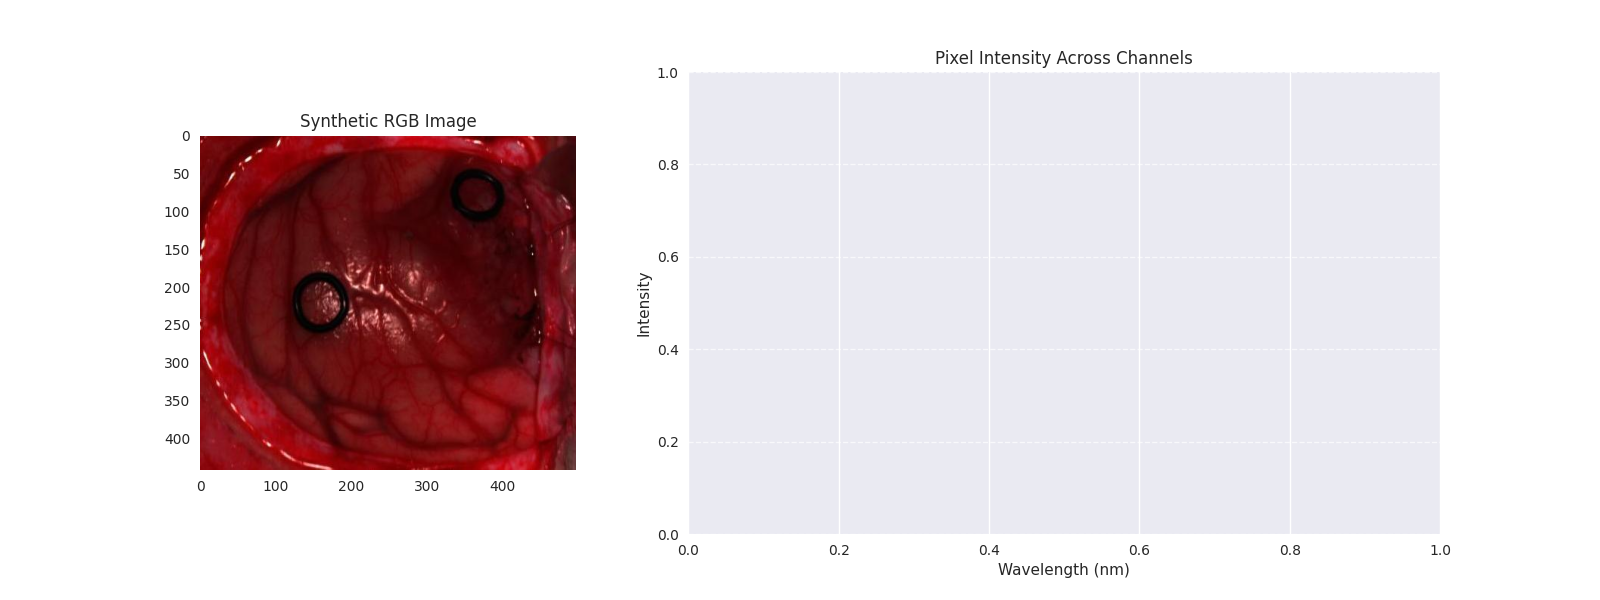

In [5]:
sample_id = "012-01"
sample = dataset.get_sample_by_id(sample_id)

%matplotlib widget
print(dataset.sample_map)

show_interactive_image_with_spectrum(
    sample["hsi_cube"],
    sample_type=SampleType.HELICOID,
    cut_wavelengths=dataset.cut_wavelengths,
    rbg_image=sample["rgb_image"],
)

## 5. Store Handselected Reference Pixels

In [ ]:
import json
from pathlib import Path

# define your data
data = {
    "016-02": {"x": 275, "y": 147},
    "022-03": {"x": 115, "y": 241},
    "028-04": {"x": 156, "y": 68},
    "028-05": {"x": 73, "y": 131},
    "029-04": {"x": 182, "y": 154},
    "034-01": {"x": 155, "y": 191},
    "034-02": {"x": 209, "y": 198},
    "034-03": {"x": 119, "y": 162},
    "035-01": {"x": 252, "y": 247},
    "037-03": {"x": 237, "y": 174},
    "037-04": {"x": 187, "y": 97},
    "053-01": {"x": 167, "y": 369},
}

# ensure output directory exists (optional)
output_dir = Path("../data/helicoid_reference_pixel")
output_dir.mkdir(exist_ok=True)

# write each entry to its own JSON file
for key, coords in data.items():
    filename = output_dir / f"{key}.json"
    with open(filename, "w") as f:
        json.dump(coords, f, indent=2)

print(f"Wrote {len(data)} files to '{output_dir.resolve()}'")

Wrote 12 files to '/home/macht/thesis/hsi-biopsy/data/helicoid_reference_pixel'


## 6. Plot with Reference Pixel

2025-07-04 15:06:51.501 | WARNING  | src.dataset.helicoid_dataset:_get_reference_pixel:439 - Warning: No blood pixels found for reference pixel selection
2025-07-04 15:06:51.503 | INFO     | src.dataset.helicoid_dataset:_get_reference_pixel:453 - Using reference pixel from file for sample 053-01: (369, 167)


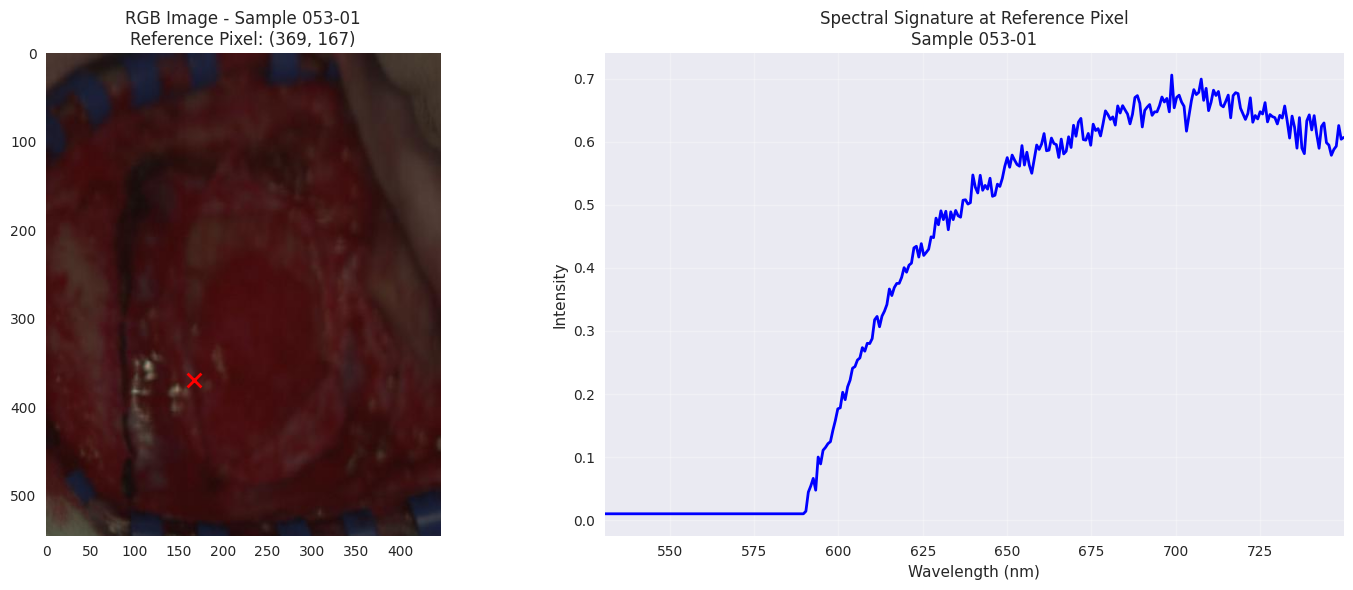

2025-07-04 15:06:52.803 | INFO     | src.dataset.helicoid_dataset:plot_sample_with_reference_pixel:773 - Plotted sample 053-01:
2025-07-04 15:06:52.806 | INFO     | src.dataset.helicoid_dataset:plot_sample_with_reference_pixel:774 -   Reference pixel (processed coordinates): (369, 167)
2025-07-04 15:06:52.807 | INFO     | src.dataset.helicoid_dataset:plot_sample_with_reference_pixel:775 -   Spectral range: 530.7 - 749.7 nm
2025-07-04 15:06:52.808 | INFO     | src.dataset.helicoid_dataset:plot_sample_with_reference_pixel:778 -   Number of spectral bands: 302


In [ ]:
sample_id = '053-01'
dataset.plot_sample_with_reference_pixel(id=sample_id)